# S&P 500 Equity+Options: Sequence Models

Every family so far has read one row at a time. A **sequence model** reads a window of rows
instead: for a stock and a decision date, the sixty trading days of that stock's own option
surface and price history that end before the date being predicted. The question this notebook
puts is whether that window carries anything the single row does not.

**Two architectures answer it, and the pairing is the point.** `nlinear` subtracts the last
observation from the window and fits one linear map from what is left to the target. It has no
memory and no notion of order beyond the positions in that map, and it exists in the sequence
literature because architectures with both are frequently unable to beat it. `lstm_h64` has both:
gated memory that carries state along the window and decides at each step what to keep. If the
gated model does not separate from the linear one here, then whatever is in the window is
reachable without memory, and the extra machinery bought nothing on this panel.

**A window is not free, and what it costs is rows.** A stock needs sixty prior observations before
its first prediction. Inside a fold's training window the earliest rows are spent reaching that
depth rather than being predicted. The validation rows keep theirs: each stock's validation
history is primed with the observations immediately before the validation window opens, so its
first validation date is predicted like any other. What a stock can lose is every row - one that
entered the roster too late, or whose history has a hole inside the window, never accumulates a
usable one. The plan in section 2 reports the rows that survive that, which is the sample these
models are actually measured on.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a sequence model reads that a tabular model does not, and what the lookback costs in
  rows before any fitting happens.
- Explain why a linear architecture with no memory is the baseline a recurrent one has to clear,
  rather than a weak alternative to it.
- Read a curve of out-of-sample ranking accuracy against training epoch and tell a model still
  learning apart from one fitting its training window.
- Say why comparing configurations at their own individual best epochs is a choice made after
  seeing the answer, and where in this case study that choice is legitimately made instead.

**Book reference**: Chapter 13, Sections 13.3-13.5 (recurrent networks for time series), and
Chapter 6, Section 6.7 (Search accounting and run logging) for the run log this notebook writes
into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) established the walk-forward folds, and
[`08_tabular_dl`](08_tabular_dl.ipynb) fitted the point-in-time neural population this one is the
sequence counterpart to.

**What it writes**: one training run per label-configuration pair and one complete validation
prediction set per pair and epoch checkpoint, in `run_log/registry.db` and under
`run_log/training/` and `run_log/predictions/`, grouped under a named population.
The `deep_learning` menu declares a third configuration, `patchtst`, on one label;
[`10_dl_patchtst`](10_dl_patchtst.ipynb) publishes that slice, and the two notebooks together
cover the declared family. **Selection happens in [`14_backtest`](14_backtest.ipynb), not here.**

In [1]:
"""Fit the declared option-analytics sequence population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="09_dl_lstm",
)

## 1. Which labels, and which models

The labels are the ones whose training menu declares `deep_learning`, and fitting all of them in
one run is what makes this population comparable against the linear, gradient boosting and TabM
ones: the families differ, the targets do not. `fwd_ret_5d` is the stock's total return over the
five trading days after the decision date, `fwd_ret_10d` the same over ten, and
`fwd_ret_risk_adj_5d` divides the five-day return by a measure of its own dispersion. The two
`fwd_dir_*` classification labels declare linear and gradient boosting only, so they are absent
here rather than dropped.

In [4]:
declared_labels(study, "deep_learning")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

`SEQUENCE_CONFIGS` is this notebook's slice of the declared family. The menu declares three
architectures; the third, `patchtst`, is declared on one label only and is published by
[`10_dl_patchtst`](10_dl_patchtst.ipynb). Splitting them is a chapter decision rather than a
modelling one - the two notebooks resolve against the same menu and the same folds, and their
populations together are the declared family.

Each name resolves to a preset under `case_studies/config/`. `lookback` is how many prior
observations enter one input window and is the same across all three, so the sample they are
measured on is the same and a difference between them is a difference between architectures.
`hidden_size` is the width of the LSTM's state and `n_layers` how many recurrent layers it is
passed through. `dropout` is the fraction of units switched off at random on each training pass.

`n_epochs` and `checkpoint_interval` are declared alongside the architecture rather than passed in
here, because they decide how many prediction sets each configuration owes: 100 epochs saved every
5 is 20, and a run that quietly trained for fewer would publish a different population under the
same name.

In [5]:
SEQUENCE_CONFIGS = ("nlinear", "lstm_h64")
declared = load_model_configs(study, "deep_learning", config_names=list(SEQUENCE_CONFIGS))
configs = load_model_configs(
    study,
    "deep_learning",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or list(SEQUENCE_CONFIGS),
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""deep_learning""","""fwd_ret_10d""","""nlinear""","""""","""architecture=nlinear, dropout=…"
"""deep_learning""","""fwd_ret_10d""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"
"""deep_learning""","""fwd_ret_5d""","""nlinear""","""""","""architecture=nlinear, dropout=…"
"""deep_learning""","""fwd_ret_5d""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"
"""deep_learning""","""fwd_ret_risk_adj_5d""","""nlinear""","""""","""architecture=nlinear, dropout=…"
"""deep_learning""","""fwd_ret_risk_adj_5d""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"


`LABELS` and `CONFIG_NAMES` narrow the run below this notebook's own slice, and a narrowed run
declares a different set of members than the published population does. A population is immutable
once written, so such a run must publish under its own name: on a fresh workspace it would
otherwise register an incomplete snapshot under the published one, and where that population
already exists the registry refuses it. The comparison is over label-configuration pairs rather
than row counts, because two different subsets can have the same height.

The device is checked in the same cell. A network trained on a GPU and the same network trained on
a CPU accumulate their sums in different orders and reach different weights, so the device is part
of what the fitted model is and is recorded inside the computation's identity rather than beside
it. The runner refuses to substitute a CPU for a requested GPU rather than publishing a different
model under the published name, so on a machine with no NVIDIA card this notebook stops at the
next cell; set `DEVICE="cpu"` and pass a `POPULATION_NAME` to fit the same grid there.

In [6]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

narrows = set(zip(configs["label"], configs["config_name"], strict=True)) != set(
    zip(declared["label"], declared["config_name"], strict=True)
)
if (narrows or device != PUBLISHED_DEVICE) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not this notebook's declared slice on {PUBLISHED_DEVICE!r}, so it cannot "
        f"publish the sequence population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. Binding the declarations to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, or which symbol-date pairs have both a feature row and a label -
nor, for a sequence model, which of those pairs have sixty prior observations behind them.
**Resolving** a request goes and finds all of that.

Resolving reads the inputs and fits nothing, so the plan can be inspected before any training
starts. Four things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of a label.**
  They are the width of the design matrix, the number of stocks, and the number of symbol-date
  pairs to be predicted. A row that differs is a configuration measured on a different sample from
  its neighbours, and its results are not comparable with theirs. They differ *between* labels,
  because a ten-day forward window runs out earlier than a five-day one.
- **`eligible_rows` is below what a tabular family reports on the same label.** A prediction needs
  a full, gap-free window of prior observations behind it, so what drops out is a stock too new to
  have accumulated one, or a stretch where the calendar has a hole inside the window. Comparing a
  sequence result with a tabular one is therefore comparing measurements on different samples,
  which is what `full_coverage` in section 4 marks within this family and what
  [`13_model_analysis`](13_model_analysis.ipynb) has to account for across families.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible in
  this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from everything
that can change its result, the device and the lookback included.
[`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes into one and what follows from it.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_10d""","""lstm_h64""",48,286,124821,2,20,2019-01-07 00:00:00,2020-12-16 00:00:00
"""fwd_ret_10d""","""nlinear""",48,286,124821,2,20,2019-01-07 00:00:00,2020-12-16 00:00:00
"""fwd_ret_5d""","""lstm_h64""",48,287,126185,2,20,2019-01-07 00:00:00,2020-12-23 00:00:00
"""fwd_ret_5d""","""nlinear""",48,287,126185,2,20,2019-01-07 00:00:00,2020-12-23 00:00:00
"""fwd_ret_risk_adj_5d""","""lstm_h64""",48,287,126184,2,20,2019-01-07 00:00:00,2020-12-23 00:00:00
"""fwd_ret_risk_adj_5d""","""nlinear""",48,287,126184,2,20,2019-01-07 00:00:00,2020-12-23 00:00:00


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window and cuts them into overlapping windows of
   sixty observations, each belonging to one stock and ending before the timestamp it predicts,
2. replaces missing feature values with zero, then standardizes each column to zero mean and unit
   variance - the mean and scale are measured on the training rows after that replacement and
   applied unchanged to the validation rows, so nothing measured on the validation window reaches
   the fit,
3. trains for the declared number of epochs, writing the weights to disk every fifth,
4. predicts the fold's validation rows from each saved set of weights.

**A window never crosses a stock, and it reads only what was observable.** Hidden state is reset
between stocks and between folds, so the sixty observations behind a prediction are always that
stock's own. They are not confined to the training window: each stock's validation history is
primed with the rows immediately preceding the validation window, and later validation dates read
earlier validation rows. What a window carries is feature values already on the table at the
timestamp being predicted, never a label from the interval that prediction covers, so the purge
gap the folds impose on labels is not crossed.

Step 4 is what makes one training run produce twenty results. The fold predictions are
concatenated into one series per checkpoint covering the whole validation period, and each becomes
its own registered prediction set with its own identity.

**What the call publishes is a population**: a named, immutable list of the prediction sets it is
going to produce. The list is computed from the resolved specifications before the first fit and
written down, and afterwards every member must exist and be complete. That is what makes the
member set well defined: it is the identities named here rather than whatever `deep_learning` rows
the registry happens to hold. It is also why a configuration that raises fails the whole call
rather than publishing a population one member short. Everything that finished stays registered,
and re-running trains only what is missing.

`SUPERSEDES_POPULATION` names the population hash this run replaces, and is empty because this is
the first generation published under this name. A population is the set of prediction identities,
so anything that moves a training identity - a changed epoch schedule, lookback or device as much
as a changed configuration menu - produces a different population under the same name, and the
registry refuses to write it without being told which snapshot it supersedes.

In [8]:
population_name = POPULATION_NAME or "sp500_equity_option_analytics-sequence-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Fold-major CV: 2 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=97,014 seq across 531 symbols
    val=64,430 seq across 511 symbols
    creating datasets...
    datasets ready
    nlinear:


      epoch   1/100: train_loss=0.079269


      epoch   2/100: train_loss=0.024144


      epoch   3/100: train_loss=0.012998


...

      epoch 100/100: train_loss=0.006946, val_loss=0.044825, IC=+0.0068


      best_ep=20, IC=+0.0156 (459.9s, 20 checkpoints)


  lstm_h64: best_epoch=45, IC=+0.0115 (840.3s)



  Best: lstm_h64 @ epoch 45 (IC=+0.0115)
  Saved to ~/ml4t/public/case_studies/sp500_equity_option_analytics/run_log/training/b4a8001e99fa/diagnostics


6 configurations: 6 trained, 0 read
population sp500_equity_option_analytics-sequence-validation-v1: 120 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows and the saved weights, and the runner returns the stored result
rather than training again.

## 4. What came out

One row per label, configuration and epoch checkpoint, read back from the registry and joined to
the declared parameters so the architecture stays visible beside its result. `ic_mean` is the
**information coefficient**: on each validation date, rank the stocks by the model's prediction,
rank them by the return they went on to earn, correlate the two rankings, and average that daily
correlation over the validation period. It measures whether the model orders the cross-section
correctly, on a scale where zero is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which rows
below are comparable with each other. A network that has settled into predicting nearly the same
value for every stock on a date gives that date no spread to rank, and the date drops out of the
average. `full_coverage` marks the rows measured on every date their own label offers, and
everything charted below is restricted to those.

**Coverage is judged within a label, not across them**, and so is every aggregate here. A ten-day
forward window runs out earlier than a five-day one, so one global maximum would mark a whole
label incomplete for a reason that has nothing to do with any model.

In [9]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "task",
        "complete",
        "checkpoint_value",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "auc_mean_daily",
        "direction_label",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(configs.select("config_name", "label", "params"), on=["config_name", "label"], how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("sequence execution returned a partial prediction set")
if set(catalog.get_column("prediction_hash")) != set(population.members):
    raise RuntimeError("the published catalog differs from the population declared before fitting")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
pairs = catalog.select("label", "config_name").unique().height
print(f"{catalog.height} candidate models: {pairs} label-configuration pairs")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "params",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(12)

120 candidate models: 6 label-configuration pairs
at 20 checkpoints each, on 3 labels


label,config_name,params,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,i64,f64,f64,f64,bool
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",5,0.00306,0.005971,492.0,true
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",15,-0.001435,0.00234,492.0,true
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",10,-0.002321,0.002643,492.0,true
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",20,-0.005274,0.001148,492.0,true
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",25,-0.010914,0.000797,492.0,true
…,…,…,…,…,…,…,…
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",60,-0.013114,0.005383,492.0,true
"""fwd_ret_10d""","""nlinear""","""architecture=nlinear, dropout=…",35,-0.013269,0.008565,492.0,true
"""fwd_ret_10d""","""lstm_h64""","""architecture=lstm, dropout=0.1…",25,-0.015743,0.009014,492.0,true


### Memory against no memory, on each label

One row per label and architecture. The comparison the table invites is down the pair for a single
label: the two read the same windows over the same folds and differ only in whether state is
carried along the window. Grouping on label and configuration name puts one configuration in each
row by construction, so the spread a row reports is a spread over epochs rather than over a grid.

`auc_mean_daily` is present where the label declares a direction sibling. A regression row has no
classes of its own and is scored as a ranking signal against that sibling's values -
`fwd_ret_5d` against `fwd_dir_5d`, `fwd_ret_10d` against `fwd_dir_10d` - and those siblings are
fitted in [`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) rather than here.
`fwd_ret_risk_adj_5d` declares no sibling and carries no AUC; null there means not computed.

In [10]:
by_architecture = (
    catalog.filter("full_coverage")
    .group_by("label", "config_name")
    .agg(
        checkpoints=pl.len(),
        scored_dates=pl.col("ic_n_days").max(),
        ic_high=pl.col("ic_mean").max(),
        ic_low=pl.col("ic_mean").min(),
        epoch_at_high=pl.col("checkpoint_value").sort_by("ic_mean").last(),
        n_positive=(pl.col("ic_mean") > 0).sum(),
        best_auc_daily=pl.col("auc_mean_daily").max(),
    )
    .sort("label", "config_name")
)
by_architecture

label,config_name,checkpoints,scored_dates,ic_high,ic_low,epoch_at_high,n_positive,best_auc_daily
str,str,u32,f64,f64,f64,i64,u32,f64
"""fwd_ret_10d""","""lstm_h64""",20,492.0,-0.015743,-0.035226,25,0,0.495708
"""fwd_ret_10d""","""nlinear""",20,492.0,0.00306,-0.026119,5,1,0.511471
"""fwd_ret_5d""","""lstm_h64""",20,497.0,0.002791,-0.015356,60,10,0.502662
"""fwd_ret_5d""","""nlinear""",20,497.0,0.002871,-0.011837,5,1,0.504876
"""fwd_ret_risk_adj_5d""","""lstm_h64""",20,497.0,0.011502,-0.003374,45,19,null
"""fwd_ret_risk_adj_5d""","""nlinear""",20,497.0,0.010185,-0.022322,5,2,null


**`epoch_at_high` is a diagnostic and not a result.** It says where on its own curve each
configuration happened to peak, and reading the two `ic_high` values as a contest between the
architectures compares each at the epoch chosen after seeing which epoch was best for it. That
comparison is made legitimately in [`14_backtest`](14_backtest.ipynb), where every checkpoint
of every family competes on one validation criterion, and what that contest returns is what
gets carried forward. Here the column is worth reading for a different reason: an architecture
whose high sits at the last checkpoint may not have finished learning, and one whose high sits
early has been fitting its training window since.

### What more training does

Each line traces one configuration's out-of-sample IC as epochs are added to it, in its own
label's panel. This is the figure the checkpoint dimension exists to produce, and it separates two
things a single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the network was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn in the first place, and its highest point is
wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why the
maximum is not what a configuration is judged on.

The panels share one vertical scale. Stacking them is what makes the labels comparable, and
rescaling each to fill its own row would make three different spreads look alike.

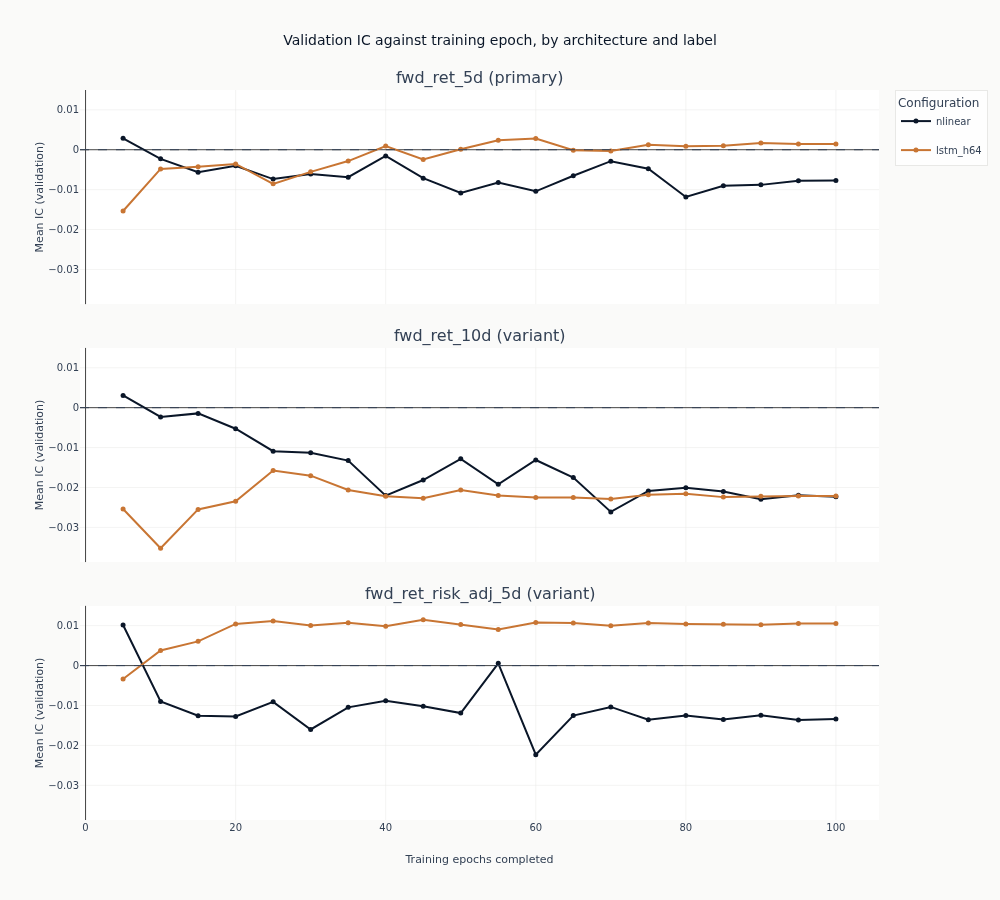

In [11]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
charted = set(curves.get_column("config_name"))
# Menu order, which is the order section 1 showed and the order that puts the memoryless baseline
# first. Sorting on the formatted parameter string would order by architecture name instead.
config_order = [
    name
    for name in configs.get_column("config_name").unique(maintain_order=True)
    if name in charted
]
line_colors = [COLORS["blue"], COLORS["copper"], COLORS["amber"], COLORS["positive"]]
if len(config_order) > len(line_colors):
    raise ValueError(
        f"{len(config_order)} configurations against {len(line_colors)} distinct line colours; "
        "add colours rather than letting two configurations share one"
    )
color_of = dict(zip(config_order, line_colors, strict=False))

fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in config_order:
        series = panel.filter(pl.col("config_name") == config_name).sort("checkpoint_value")
        if not series.height:
            continue
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines+markers",
                name=config_name,
                legendgroup=config_name,
                showlegend=row == 1,
                line=dict(color=color_of[config_name], width=2),
                marker=dict(size=5, color=color_of[config_name]),
            ),
            row=row,
            col=1,
        )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    # `shared_yaxes` matches axes across columns, so with one column it does nothing. Matching
    # every row to the first is what puts the labels on one vertical scale.
    if row > 1:
        fig_curves.update_yaxes(matches="y", row=row, col=1)
fig_curves.update_xaxes(title_text="Training epochs completed", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against training epoch, by architecture and label",
    height=300 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Configuration"),
)
# The span of each panel and how many of its lines cross zero are facts about the frame, so the
# description reads them rather than asserting a shape the next run may not have.
panel_facts = {
    row["label"]: row
    for row in curves.group_by("label")
    .agg(
        lowest=pl.col("ic_mean").min(),
        highest=pl.col("ic_mean").max(),
        total=pl.col("config_name").n_unique(),
        below=pl.col("config_name").filter(pl.col("ic_mean") < 0).n_unique(),
    )
    .to_dicts()
}
panel_text = ". ".join(
    "The {} panel spans {:+.3f} to {:+.3f}, with {} of its {} lines dipping below zero at some "
    "checkpoint".format(
        label,
        panel_facts[label]["lowest"],
        panel_facts[label]["highest"],
        panel_facts[label]["below"],
        panel_facts[label]["total"],
    )
    for label in panel_labels
)
show_plotly_with_alt(
    fig_curves,
    "Stacked line charts, one panel per label sharing a vertical scale, of mean validation "
    "information coefficient against training epochs completed, one line per architecture with a "
    f"dashed zero line in each panel. Counted from the frame: {panel_text}.",
)

## 5. What to notice

**The baseline is doing a job, not filling a slot.** `nlinear` removes the level of each window
and fits one linear map over what remains. Everything the recurrent model has that it does not -
state carried along the window, gates that decide what to keep - has to show up as a separation
between the two curves on the same label, or it did not earn its cost on this panel.

**The lookback is a sample decision as much as a modelling one.** Sixty observations per window
means the earliest rows of each fold go unpredicted and short-lived names may not qualify at all,
so this family is measured on fewer rows than the tabular families are. That is visible in the
plan's `eligible_rows` and is why a cross-family IC comparison needs the coverage column rather
than the number alone.

**Nothing here is selected.** Every checkpoint of both architectures on every declared label is
registered, and what advances is decided in [`14_backtest`](14_backtest.ipynb) on validation
backtest Sharpe after costs. The curves above show what training length does to a ranking measure;
they decide nothing.

**Next**: [`10_dl_patchtst`](10_dl_patchtst.ipynb) publishes the remaining slice of the declared
family, and [`13_model_analysis`](13_model_analysis.ipynb) compares all of it against the other
families.